
# Introduction
<p align="center">
<img src="https://raw.githubusercontent.com/pbcquoc/vietocr/master/image/vietocr.jpg" width="512" height="512">
</p>
This notebook describe how you can use VietOcr to train OCR model




In [11]:
! pip install Pillow vietocr 

  Using cached pillow-11.2.1-cp39-cp39-win_amd64.whl.metadata (9.1 kB)
  Using cached vietocr-0.3.13-py3-none-any.whl.metadata (4.1 kB)
  Using cached pillow-10.2.0-cp39-cp39-win_amd64.whl.metadata (9.9 kB)
Using cached vietocr-0.3.13-py3-none-any.whl (34 kB)
Using cached pillow-10.2.0-cp39-cp39-win_amd64.whl (2.6 MB)

   ---------------------------------------- 0/2 [Pillow]
   ---------------------------------------- 0/2 [Pillow]
   ---------------------------------------- 2/2 [vietocr]



# Inference

In [1]:
import matplotlib.pyplot as plt
from PIL import Image

from vietocr.tool.config import Cfg
from vietocr.tool.predictor import Predictor

In [ ]:
# config = Cfg.load_config_from_name('vgg_transformer')

Change weights to your weights or using default weights from our pretrained model. Path can be url or local file

In [ ]:
# # config['weights'] = './weights/transformerocr.pth'
# config['cnn']['pretrained']=False
# config['device'] = 'cuda:0'

In [ ]:
# detector = Predictor(config)

/usr/local/lib/python3.8/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and will be removed in 0.15, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.8/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
18533it [00:14, 1278.72it/s]


# Download sample dataset

# Train model



1.   Load your config
2.   Train model using your dataset above



Load the default config, we adopt VGG for image feature extraction

In [1]:
from vietocr.tool.config import Cfg
from vietocr.model.trainer import Trainer
import torch
import os

# Change the config

* *data_root*: the folder save your all images
* *train_annotation*: path to train annotation
* *valid_annotation*: path to valid annotation
* *print_every*: show train loss at every n steps
* *valid_every*: show validation loss at every n steps
* *iters*: number of iteration to train your model
* *export*: export weights to folder that you can use for inference
* *metrics*: number of sample in validation annotation you use for computing full_sequence_accuracy, for large dataset it will take too long, then you can reuduce this number


In [2]:
config = Cfg.load_config_from_name('vgg_transformer')

In [12]:
dataset_params = {
    'name':'lmdb',
    'data_root':os.path.abspath('../data/img'),
    # 'train_annotation':'annotation_train.txt',
    # 'valid_annotation':'annotation_valid.txt',
    # 'train_annotation':'',
    # 'valid_annotation': ''
}

params = {
         'print_every':200,
         'valid_every':15*200,
          'iters':20000,
          'checkpoint':'./checkpoint/transformerocr_checkpoint.pth',
          'export':'./weights/transformerocr.pth',
          'metrics': 10000
         }

config['trainer'].update(params)
config['dataset'].update(dataset_params)
config['dataloader']['num_workers'] = 0

config['device'] = 'cuda:0' if torch.cuda.is_available() else 'cpu'

you can change any of these params in this full list below

In [13]:
config

{'vocab': 'aAàÀảẢãÃáÁạẠăĂằẰẳẲẵẴắẮặẶâÂầẦẩẨẫẪấẤậẬbBcCdDđĐeEèÈẻẺẽẼéÉẹẸêÊềỀểỂễỄếẾệỆfFgGhHiIìÌỉỈĩĨíÍịỊjJkKlLmMnNoOòÒỏỎõÕóÓọỌôÔồỒổỔỗỖốỐộỘơƠờỜởỞỡỠớỚợỢpPqQrRsStTuUùÙủỦũŨúÚụỤưƯừỪửỬữỮứỨựỰvVwWxXyYỳỲỷỶỹỸýÝỵỴzZ0123456789!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~ ',
 'device': 'cuda:0',
 'seq_modeling': 'transformer',
 'transformer': {'d_model': 256,
  'nhead': 8,
  'num_encoder_layers': 6,
  'num_decoder_layers': 6,
  'dim_feedforward': 2048,
  'max_seq_length': 1024,
  'pos_dropout': 0.1,
  'trans_dropout': 0.1},
 'optimizer': {'max_lr': 0.0003, 'pct_start': 0.1},
 'trainer': {'batch_size': 32,
  'print_every': 200,
  'valid_every': 3000,
  'iters': 20000,
  'export': './weights/transformerocr.pth',
  'checkpoint': './checkpoint/transformerocr_checkpoint.pth',
  'log': './train.log',
  'metrics': 10000},
 'dataset': {'name': 'lmdb',
  'data_root': 'c:\\University-HCMUTE\\KLTN\\code\\sign-recognition\\OCR\\data\\img',
  'train_annotation': 'annotation_train.txt',
  'valid_annotation': 'annotation_val_small

You should train model from our pretrained

In [14]:
trainer = Trainer(config, pretrained=True)

c:\Users\tuf\miniconda3\envs\myenv\lib\site-packages\torch\nn\modules\transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Model weight C:\Users\tuf\AppData\Local\Temp\vgg_transformer.pth exsits. Ignore download!
train_lmdb exists. Remove folder if you want to create new dataset


train_lmdb build cluster: 100%|███████████████████████████| 42413/42413 [00:00<00:00, 145659.57it/s]

valid_lmdb exists. Remove folder if you want to create new dataset



valid_lmdb build cluster: 100%|██████████████████████████████| 4709/4709 [00:00<00:00, 62565.86it/s]


Save model configuration for inference, load_config_from_file

In [15]:
trainer.config.save('config.yml')

Visualize your dataset to check data augmentation is appropriate

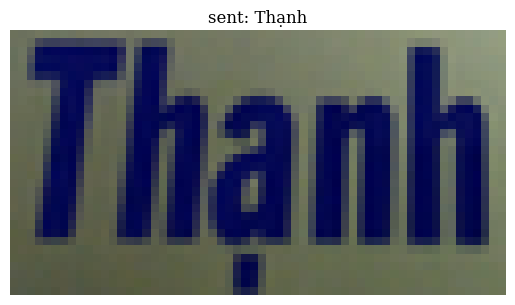

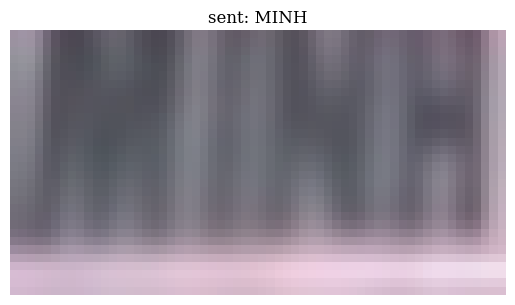

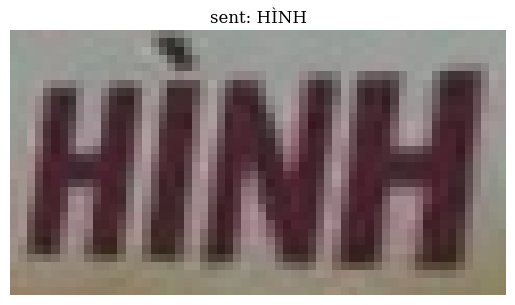

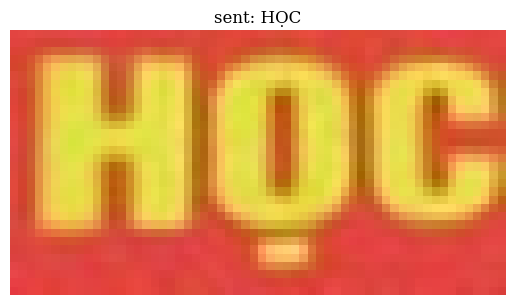

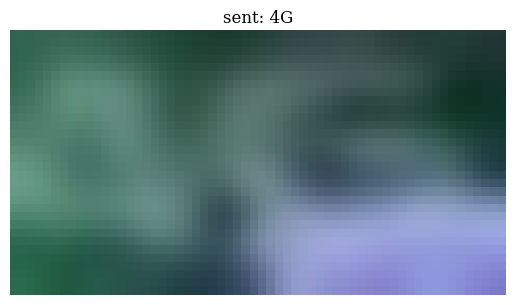

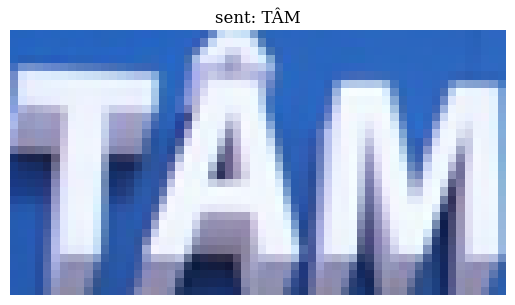

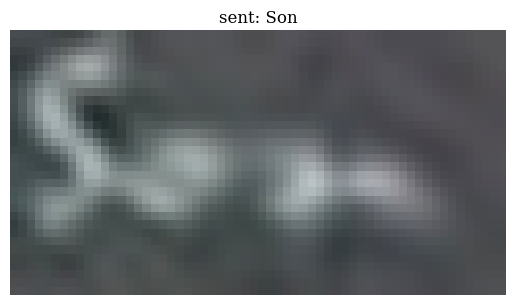

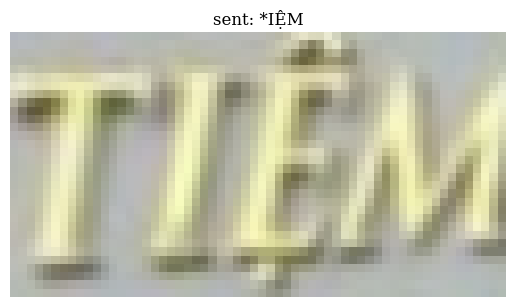

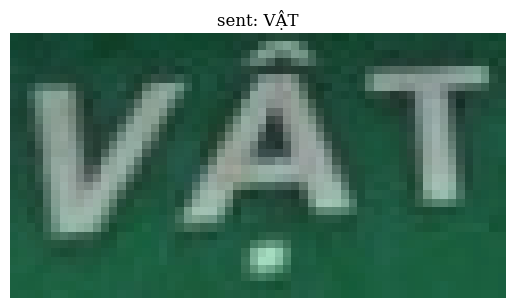

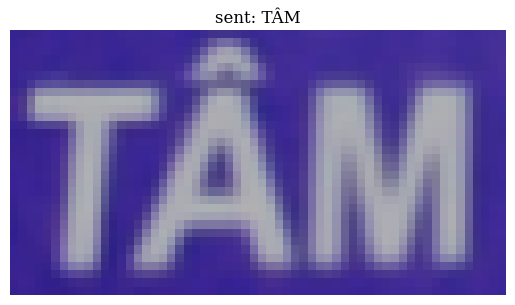

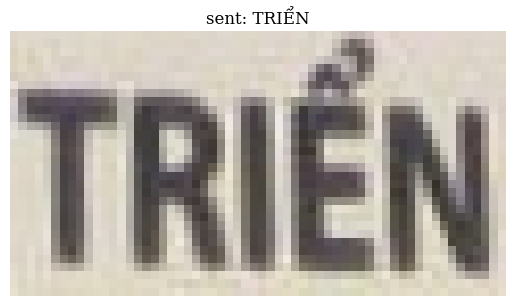

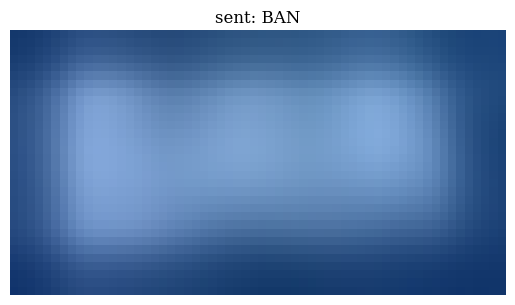

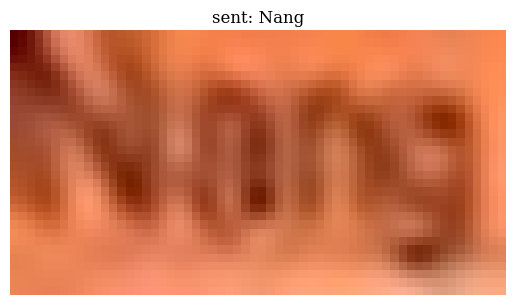

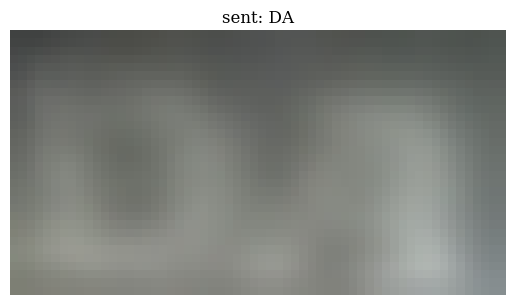

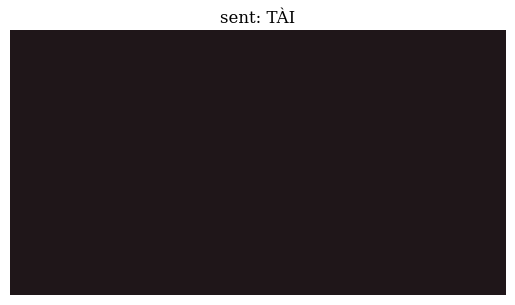

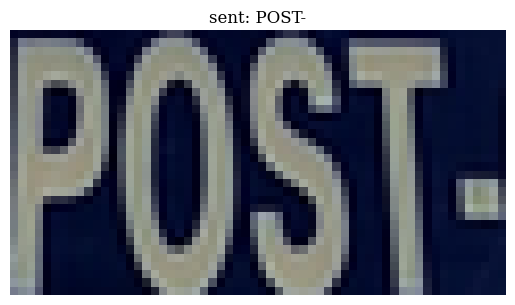

In [16]:
trainer.visualize_dataset()

Train now

In [17]:
trainer.train()

iter: 000200 - train loss: 0.838 - lr: 1.91e-05 - load time: 12.48 - gpu time: 41.16
iter: 000400 - train loss: 0.756 - lr: 3.95e-05 - load time: 8.82 - gpu time: 35.60
iter: 000600 - train loss: 0.731 - lr: 7.14e-05 - load time: 8.83 - gpu time: 33.17
iter: 000800 - train loss: 0.723 - lr: 1.12e-04 - load time: 9.96 - gpu time: 34.74
iter: 001000 - train loss: 0.722 - lr: 1.56e-04 - load time: 8.66 - gpu time: 36.29
iter: 001200 - train loss: 0.712 - lr: 2.01e-04 - load time: 8.93 - gpu time: 36.15
iter: 001400 - train loss: 0.713 - lr: 2.41e-04 - load time: 8.54 - gpu time: 34.90
iter: 001600 - train loss: 0.708 - lr: 2.73e-04 - load time: 7.61 - gpu time: 34.97
iter: 001800 - train loss: 0.716 - lr: 2.93e-04 - load time: 7.12 - gpu time: 34.74
iter: 002000 - train loss: 0.710 - lr: 3.00e-04 - load time: 8.26 - gpu time: 33.10
iter: 002200 - train loss: 0.711 - lr: 3.00e-04 - load time: 8.37 - gpu time: 34.51
iter: 002400 - train loss: 0.697 - lr: 3.00e-04 - load time: 8.98 - gpu tim

Visualize prediction from our trained model


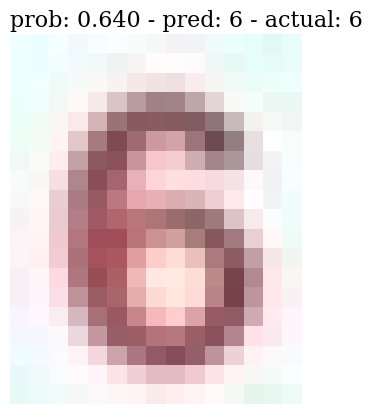

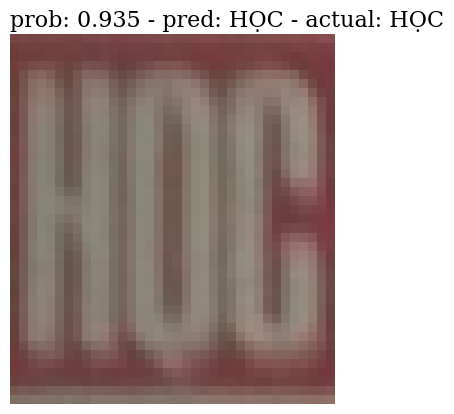

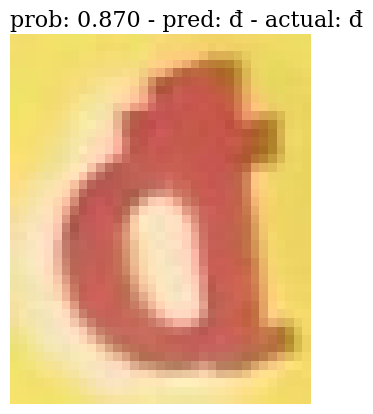

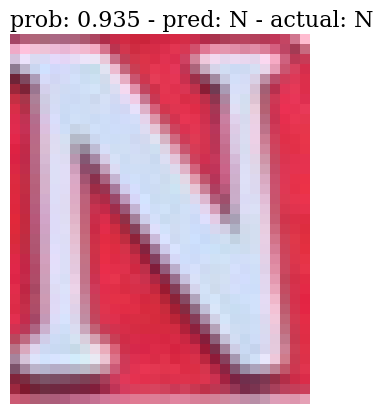

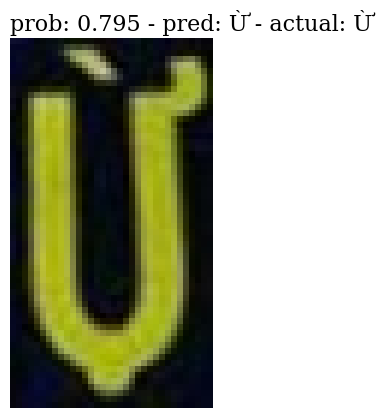

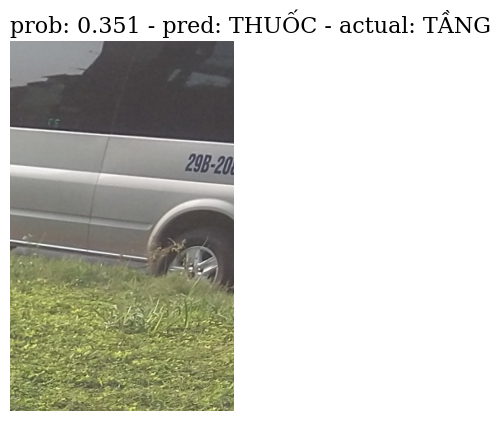

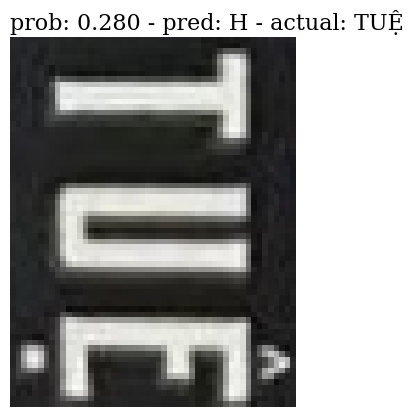

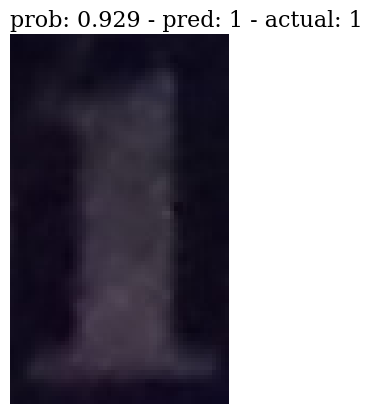

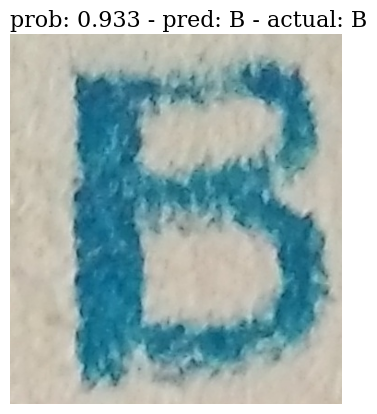

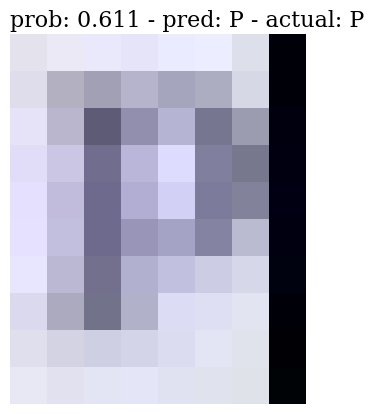

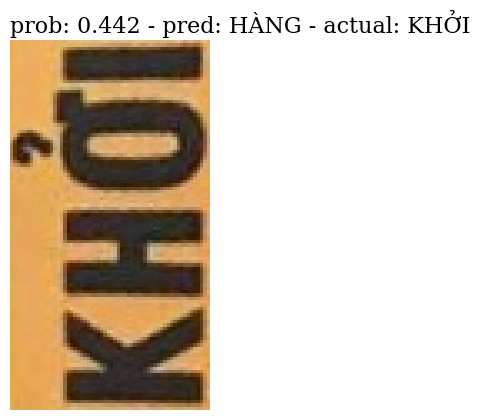

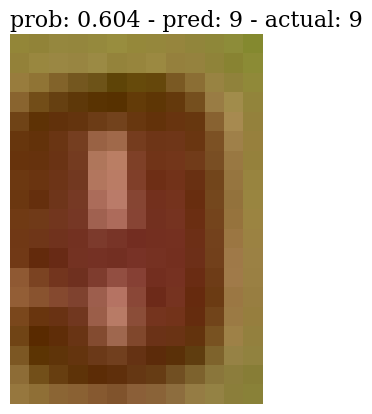

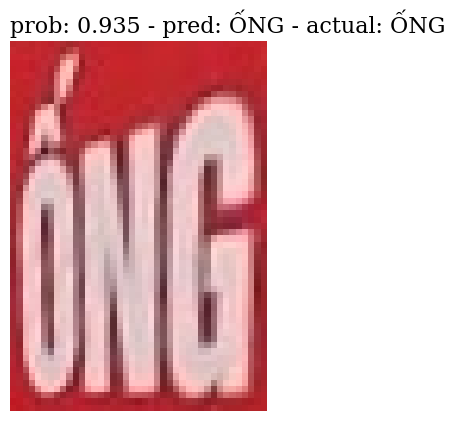

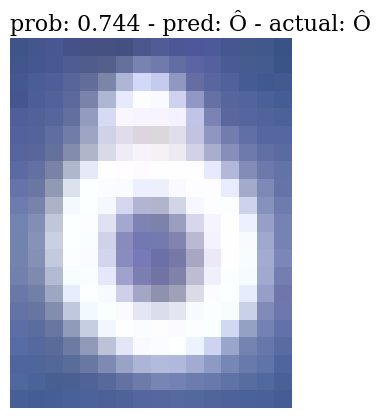

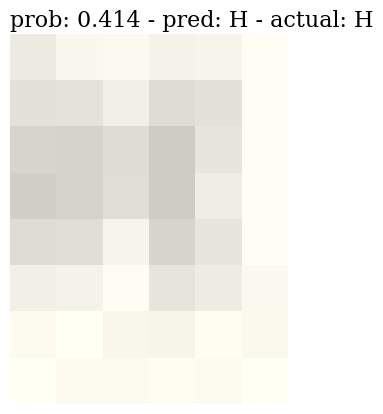

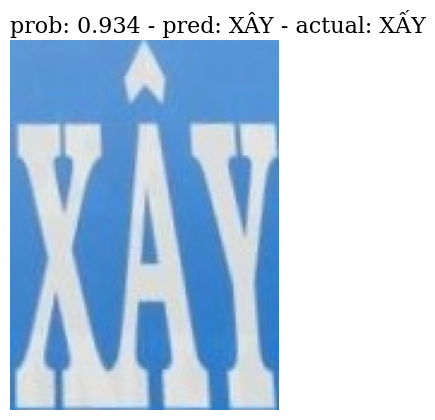

In [18]:
trainer.visualize_prediction()

Compute full seq accuracy for full valid dataset

In [19]:
trainer.precision()

(0.8261861313868614, 0.8899162)